In [1]:
import pennylane as qml 
from pennylane import numpy as np 
import time 
from scipy.optimize import minimize
import matplotlib.pyplot as plt 
import networkx as nx 

np.random.seed(42)

C:\Users\Probook\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


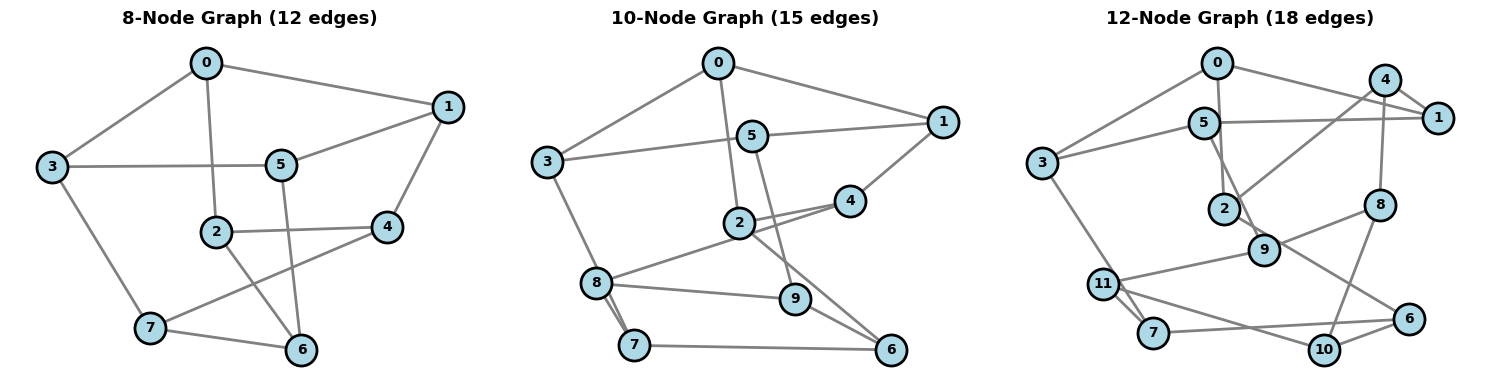

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

# Generate graphs
graphs = {
    8: [
        (0,1), (0,2), (0,3),
        (1,4), (1,5),
        (2,4), (2,6),
        (3,5), (3,7),
        (4,7),
        (5,6),
        (6,7)
    ],
    10: [
        (0,1), (0,2), (0,3),
        (1,4), (1,5),
        (2,4), (2,6),
        (3,5), (3,7),
        (4,8),
        (5,9),
        (6,7), (6,9),
        (7,8),
        (8,9)
    ],
    12: [
        (0,1), (0,2), (0,3),
        (1,4), (1,5),
        (2,4), (2,6),
        (3,5), (3,7),
        (4,8),
        (5,9),
        (6,7), (6,10),
        (7,11),
        (8,9), (8,10),
        (9,11),
        (10,11)
    ]

}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, n_wires in enumerate([8, 10, 12]):
    ax = axes[idx]
    
    # Create NetworkX graph
    G = nx.Graph()
    G.add_edges_from(graphs[n_wires])
    
    # Layout
    pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                           node_size=500, edgecolors='black', 
                           linewidths=2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, 
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                           width=2, ax=ax)
    
    ax.set_title(f'{n_wires}-Node Graph ({len(graphs[n_wires])} edges)', 
                 fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print()

In [5]:
def compute_optimal_cut(n_wires, graph):
    """Brute force search for optimal MaxCut"""
    best_cut = 0
    
    for partition in range(2**n_wires):
        # Convert partition number to bitstring
        bitstring = format(partition, f'0{n_wires}b')
        
        # Count cut edges
        cut = 0
        for edge in graph:
            if bitstring[edge[0]] != bitstring[edge[1]]:
                cut += 1
        
        if cut > best_cut:
            best_cut = cut
    
    return best_cut

# Calculate optimal cuts for all graphs
optimal_cuts = {}
print("Calculating optimal cuts")
for n_wires, graph in graphs.items():
    optimal_cuts[n_wires] = compute_optimal_cut(n_wires, graph)
    print(f"  {n_wires}-node graph: Optimal cut = {optimal_cuts[n_wires]}")

print()

Calculating optimal cuts
  8-node graph: Optimal cut = 10
  10-node graph: Optimal cut = 13
  12-node graph: Optimal cut = 16



In [7]:
def U_B(beta, n_wires):
    for wire in range(n_wires):
        qml.RX(2 * beta, wires=wire)

def U_C(gamma, graph):
    for edge in graph:
        qml.CNOT(wires=edge)
        qml.RZ(gamma, wires=edge[1])
        qml.CNOT(wires=edge)


In [24]:
def random_init(p, seed=None):
    """Random initialization between 0 and 2π"""
    if seed is not None:
        np.random.seed(seed)
    return np.random.uniform(0, 2*np.pi, 2*p)

def fixed_init(p):
    """Fixed initialization at 1.0"""
    return np.ones(2*p)

def tqa_init(p):
    """TQA-inspired: gamma increases, beta decreases"""
    gammas = np.linspace(0.1, 1.0, p)
    betas = np.linspace(0.5, 0.1, p)
    return np.concatenate([gammas, betas])

def warm_start_init(p, prev_optimal):
    """Warm-start: interpolate from p-1 optimal parameters"""
    if p == 1 or prev_optimal is None:
        # No previous solution, use random
        return random_init(p)
    
    # Previous params: [γ₁*, ..., γₚ₋₁*, β₁*, ..., βₚ₋₁*]
    prev_p = len(prev_optimal) // 2
    prev_gammas = prev_optimal[:prev_p]
    prev_betas = prev_optimal[prev_p:]
    
    # Interpolate to p layers
    # Simple strategy: repeat last values and add small perturbation
    new_gammas = np.zeros(p)
    new_betas = np.zeros(p)
    
    for i in range(p):
        idx = min(i, prev_p - 1)
        new_gammas[i] = prev_gammas[idx]
        new_betas[i] = prev_betas[idx]
    
    # Add small random perturbation
    new_gammas += np.random.normal(0, 0.05, p)
    new_betas += np.random.normal(0, 0.05, p)
    
    return np.concatenate([new_gammas, new_betas])



In [26]:
n_trials = 10  # Trials per strategy
max_iter = 300

# Store optimal parameters for warm-start
optimal_params_storage = {}

strategies = {
    'Random': ('random', random_init),
    'Fixed': ('deterministic', fixed_init),
    'TQA': ('deterministic', tqa_init),
    'Warm-Start': ('warm', warm_start_init)
}

results = {}

for n_wires in [8, 10, 12]:
    graph = graphs[n_wires]
    optimal_cut = optimal_cuts[n_wires]
    
    results[n_wires] = {}
    optimal_params_storage[n_wires] = {}
    
    # Create device
    dev = qml.device("default.qubit", wires=n_wires)
    
    # Define circuit
    @qml.qnode(dev)
    def circuit(params, p):
        params_2d = params.reshape(2, p)
        gammas = params_2d[0]
        betas = params_2d[1]
        
        for wire in range(n_wires):
            qml.Hadamard(wires=wire)
        
        for gamma, beta in zip(gammas, betas):
            U_C(gamma, graph)
            U_B(beta, n_wires)
        
        C = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in graph))
        return qml.expval(C)
    
    def objective(params, p):
        return -0.5 * (len(graph) - circuit(params, p))
    
    # Test each depth
    for p in [1, 2]:
        print(f"\n{'='*70}")
        print(f"Graph: {n_wires} nodes | Depth: p={p}")
        print(f"{'='*70}")
        
        results[n_wires][p] = {}
        
        # ---- CHANGED: track best across ALL strategies ----
        best_ratio_this_p = 0
        best_params_this_p = None
        # ---------------------------------------------------
        
        # Test each strategy
        for strategy_name, (strategy_type, init_func) in strategies.items():
            print(f"\n  Strategy: {strategy_name}")
            
            results[n_wires][p][strategy_name] = []
            
            # Determine number of trials
            if strategy_type == 'deterministic':
                trials = 1
            else:
                trials = n_trials
            
            for trial in range(trials):
                if trials > 1:
                    print(f"    Trial {trial + 1}/{trials}", end=" ")
                
                # Initialize parameters
                if strategy_name == 'Warm-Start':
                    prev_optimal = optimal_params_storage[n_wires].get(p-1, None)
                    init_params = init_func(p, prev_optimal)
                elif strategy_type == 'random':
                    init_params = init_func(p, seed=trial*10)
                else:
                    init_params = init_func(p)
                
                # Track convergence
                convergence_history = {'iteration': [], 'cost': [], 'time': []}
                iteration_count = [0]
                start_time = time.time()
                
                def callback(params):
                    iteration_count[0] += 1
                    current_time = time.time() - start_time
                    cost = objective(params, p)
                    
                    convergence_history['iteration'].append(iteration_count[0])
                    convergence_history['cost'].append(cost)
                    convergence_history['time'].append(current_time)
                
                # Optimize using L-BFGS-B
                opt_start = time.time()
                result = minimize(
                    lambda params: objective(params, p),
                    init_params,
                    method='L-BFGS-B',
                    callback=callback,
                    options={'maxiter': max_iter}
                )
                opt_time = time.time() - opt_start
                
                # Final results
                final_cut = -objective(result.x, p)
                approx_ratio = final_cut / optimal_cut
                
                # Convergence speed: iterations to 95% of final
                target_cost = result.fun * 0.95
                convergence_iter = next(
                    (i for i, cost in enumerate(convergence_history['cost']) 
                     if cost <= target_cost), 
                    len(convergence_history['cost'])
                )
                
                # Time to 95%
                time_to_95 = convergence_history['time'][convergence_iter] if convergence_iter < len(convergence_history['time']) else opt_time
                
                # Success: did it reach 90% approximation ratio?
                success = approx_ratio >= 0.90
                
                # Store trial results
                trial_result = {
                    'approx_ratio': approx_ratio,
                    'final_cut': final_cut,
                    'time': opt_time,
                    'iterations': result.nfev,
                    'convergence_iter': convergence_iter,
                    'time_to_95': time_to_95,
                    'success': success,
                    'convergence_history': convergence_history,
                    'final_params': result.x,
                    'init_params': init_params
                }
                
                results[n_wires][p][strategy_name].append(trial_result)
                
                if trials > 1:
                    print(f"- Ratio: {approx_ratio:.3f}, Time: {opt_time:.1f}s, Iters: {result.nfev}")
                else:
                    print(f"    Ratio: {approx_ratio:.4f}, Time: {opt_time:.2f}s, Iterations: {result.nfev}")
                
                # ---- CHANGED: track best params across ALL strategies ----
                if approx_ratio > best_ratio_this_p:
                    best_ratio_this_p = approx_ratio
                    best_params_this_p = result.x.copy()
                # ----------------------------------------------------------
        
        # ---- CHANGED: store best params from ALL strategies for warm-start ----
        optimal_params_storage[n_wires][p] = best_params_this_p
        # -----------------------------------------------------------------------


Graph: 8 nodes | Depth: p=1

  Strategy: Random
- Ratio: 0.831, Time: 0.8s, Iters: 42
- Ratio: 0.831, Time: 0.6s, Iters: 33
- Ratio: 0.831, Time: 0.5s, Iters: 27
- Ratio: 0.831, Time: 0.6s, Iters: 30
- Ratio: 0.831, Time: 0.6s, Iters: 30
- Ratio: 0.831, Time: 0.6s, Iters: 30
- Ratio: 0.831, Time: 0.6s, Iters: 30
- Ratio: 0.831, Time: 0.5s, Iters: 27
- Ratio: 0.831, Time: 0.7s, Iters: 30
- Ratio: 0.831, Time: 0.7s, Iters: 27

  Strategy: Fixed
    Ratio: 0.8309, Time: 0.65s, Iterations: 30

  Strategy: TQA
    Ratio: 0.8309, Time: 0.64s, Iterations: 30

  Strategy: Warm-Start
- Ratio: 0.831, Time: 0.8s, Iters: 42
- Ratio: 0.831, Time: 0.9s, Iters: 48
- Ratio: 0.831, Time: 0.6s, Iters: 30
- Ratio: 0.831, Time: 0.9s, Iters: 48
- Ratio: 0.831, Time: 0.5s, Iters: 24
- Ratio: 0.831, Time: 0.6s, Iters: 27
- Ratio: 0.600, Time: 0.4s, Iters: 18
- Ratio: 0.831, Time: 0.8s, Iters: 39
- Ratio: 0.831, Time: 0.8s, Iters: 39
- Ratio: 0.831, Time: 0.5s, Iters: 27

Graph: 8 nodes | Depth: p=2

  Strat

In [28]:
stats = {}

for n_wires in [8, 10, 12]:
    stats[n_wires] = {}
    
    for p in [1, 2]:
        stats[n_wires][p] = {}
        
        for strategy_name in strategies.keys():
            trials = results[n_wires][p][strategy_name]
            
            stats[n_wires][p][strategy_name] = {
                'mean_ratio': np.mean([t['approx_ratio'] for t in trials]),
                'std_ratio': np.std([t['approx_ratio'] for t in trials]),
                'mean_time': np.mean([t['time'] for t in trials]),
                'std_time': np.std([t['time'] for t in trials]),
                'mean_iters': np.mean([t['iterations'] for t in trials]),
                'std_iters': np.std([t['iterations'] for t in trials]),
                'mean_conv_iter': np.mean([t['convergence_iter'] for t in trials]),
                'mean_time_to_95': np.mean([t['time_to_95'] for t in trials]),
                'success_rate': sum([t['success'] for t in trials]) / len(trials) * 100
            }

In [15]:
stats = {}
 
for n_wires in [8, 10, 12]:
    stats[n_wires] = {}
    for p in [1, 2]:
        stats[n_wires][p] = {}
        for sname in strategies.keys():
            trials = results[n_wires][p][sname]
            success_rate = sum(t['success'] for t in trials) / len(trials) * 100
 
            stats[n_wires][p][sname] = {
                'mean_ratio':           np.mean([t['approx_ratio']      for t in trials]),
                'std_ratio':            np.std( [t['approx_ratio']      for t in trials]),
                'mean_time':            np.mean([t['time']              for t in trials]),
                'std_time':             np.std( [t['time']              for t in trials]),
                'mean_iters':           np.mean([t['iterations']        for t in trials]),
                'std_iters':            np.std( [t['iterations']        for t in trials]),
                'mean_convergence_iter':np.mean([t['convergence_iter']  for t in trials]),
                'mean_time_to_95':      np.mean([t['time_to_95']        for t in trials]),
                'success_rate':         success_rate,
                'n_trials':             len(trials)
            }


In [32]:
for n_wires in [8, 10, 12]:
    for p in [1, 2]:
        print(f"\n{n_wires}-node graph, p={p} (Optimal cut = {optimal_cuts[n_wires]}):")
        print("-"*110)
        print(f"{'Strategy':<15} {'Avg Ratio':<15} {'Time (s)':<12} "
              f"{'Iters':<10} {'Conv Iter':<12} {'Time to 95%':<12} {'Success %':<10}")
        print("-"*110)
        
        for strategy_name in strategies.keys():
            s = stats[n_wires][p][strategy_name]
            print(f"{strategy_name:<15} "
                  f"{s['mean_ratio']:.4f}±{s['std_ratio']:.4f}   "
                  f"{s['mean_time']:.2f}±{s['std_time']:.2f}   "
                  f"{s['mean_iters']:.0f}±{s['std_iters']:.0f}   "
                  f"{s['mean_conv_iter']:.0f}           "
                  f"{s['mean_time_to_95']:.2f}s         "
                  f"{s['success_rate']:.0f}%")
        print("-"*110)


8-node graph, p=1 (Optimal cut = 10):
--------------------------------------------------------------------------------------------------------------
Strategy        Avg Ratio       Time (s)     Iters      Conv Iter    Time to 95%  Success % 
--------------------------------------------------------------------------------------------------------------
Random          0.8309±0.0000   0.62±0.08   31±4   1           0.23s         0%
Fixed           0.8309±0.0000   0.65±0.00   30±0   1           0.28s         0%
TQA             0.8309±0.0000   0.64±0.00   30±0   2           0.25s         0%
Warm-Start      0.8078±0.0693   0.66±0.17   34±10   1           0.31s         0%
--------------------------------------------------------------------------------------------------------------

8-node graph, p=2 (Optimal cut = 10):
--------------------------------------------------------------------------------------------------------------
Strategy        Avg Ratio       Time (s)     Iters      Conv Ite

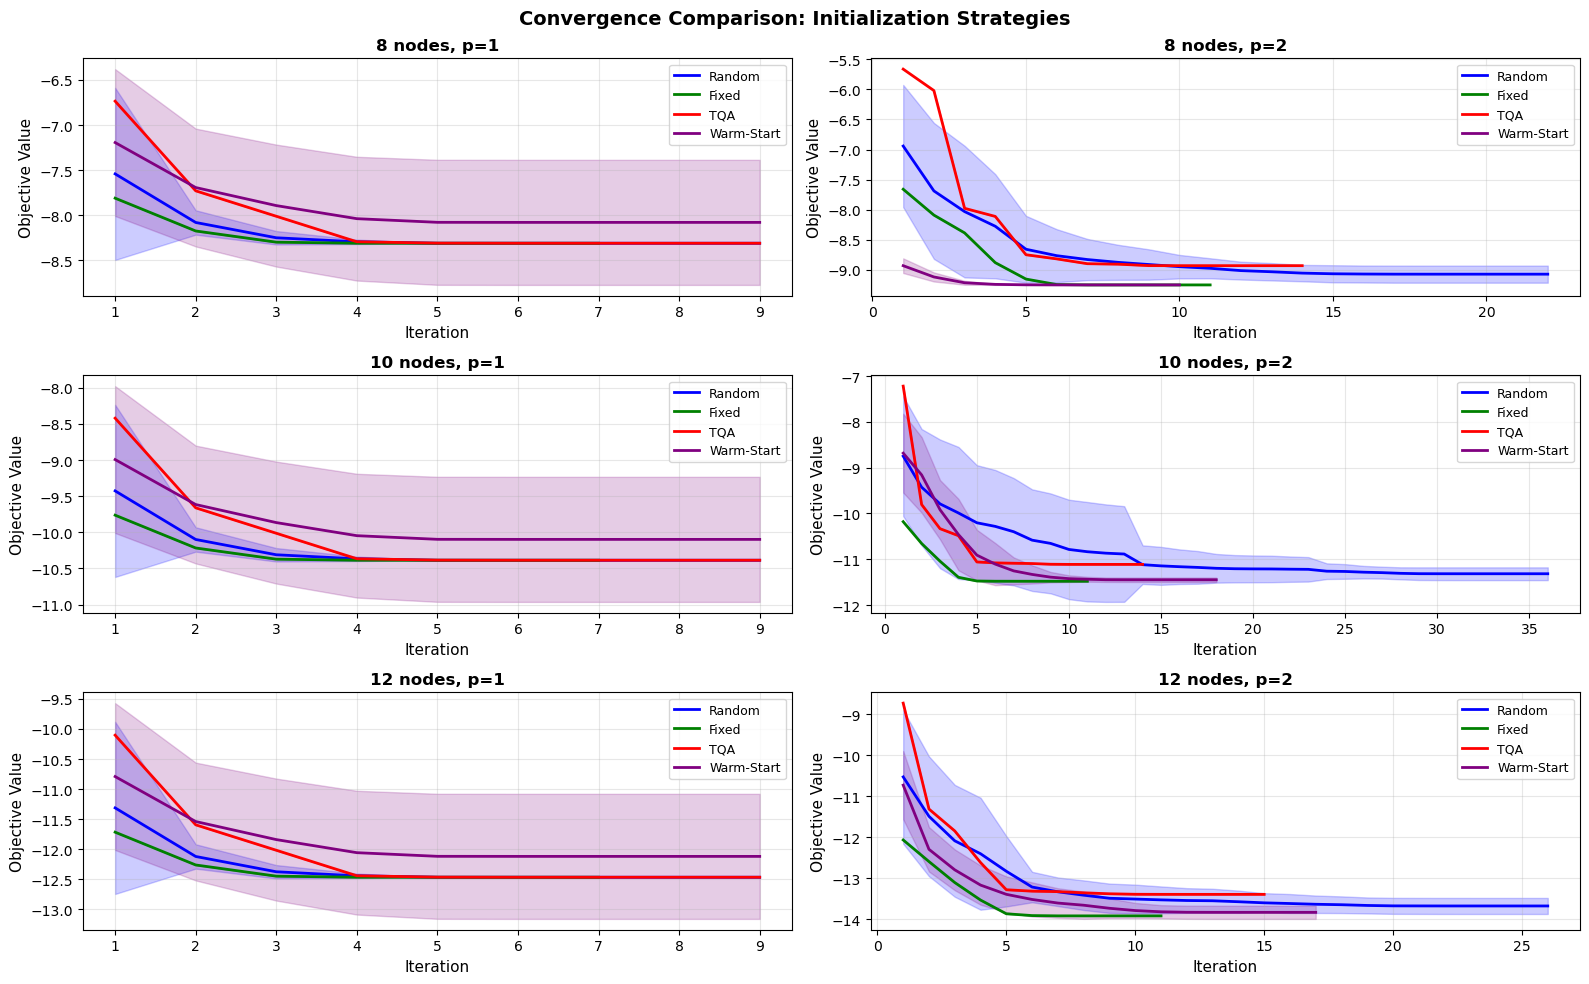

In [34]:
fig, axes = plt.subplots(3,2 , figsize=(16, 10))

colors = {'Random': 'blue', 'Fixed': 'green', 'TQA': 'red', 
          'Warm-Start': 'purple', 'Near-Optimal': 'orange'}

for row, n_wires in enumerate([8, 10, 12]):
    for col, p in enumerate([1, 2]):
        ax = axes[row, col]
        
        for strategy_name in strategies.keys():
            trials = results[n_wires][p][strategy_name]
            all_histories = [t['convergence_history'] for t in trials]
            
            # Find max iterations
            max_iters = max(len(h['cost']) for h in all_histories)
            
            # Pad histories
            padded_costs = []
            for h in all_histories:
                padded = list(h['cost'])
                if len(padded) < max_iters:
                    padded.extend([padded[-1]] * (max_iters - len(padded)))
                padded_costs.append(padded)
            
            # Mean and std
            mean_cost = np.mean(padded_costs, axis=0)
            std_cost = np.std(padded_costs, axis=0)
            iterations = range(1, len(mean_cost) + 1)
            
            # Plot
            ax.plot(iterations, mean_cost, label=strategy_name,
                   color=colors[strategy_name], linewidth=2)
            ax.fill_between(iterations,
                           mean_cost - std_cost,
                           mean_cost + std_cost,
                           color=colors[strategy_name], alpha=0.2)
        
        ax.set_xlabel('Iteration', fontsize=11)
        ax.set_ylabel('Objective Value', fontsize=11)
        ax.set_title(f'{n_wires} nodes, p={p}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)

plt.suptitle('Convergence Comparison: Initialization Strategies', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [36]:
import numpy as np

# Create comparison table
comparison_data = []

for p in [1, 2]:
    # Added 12 to include all three graph sizes
    for strategy_name in strategies.keys():
        avg_ratio = np.mean([stats[n_wires][p][strategy_name]['mean_ratio'] 
                            for n_wires in [8, 10, 12]])
        avg_time = np.mean([stats[n_wires][p][strategy_name]['mean_time'] 
                           for n_wires in [8, 10, 12]])
        avg_conv = np.mean([stats[n_wires][p][strategy_name]['mean_conv_iter'] 
                           for n_wires in [8, 10, 12]])
        avg_success = np.mean([stats[n_wires][p][strategy_name]['success_rate'] 
                              for n_wires in [8, 10, 12]])
        
        comparison_data.append({
            'p': p,
            'Strategy': strategy_name,
            'Avg Ratio': avg_ratio,
            'Avg Time (s)': avg_time,
            'Avg Conv Iter': avg_conv,
            'Success Rate (%)': avg_success
        })
    
    # Updated the lambda search functions to average across 8, 10, and 12
    best_quality = max(strategies.keys(), 
                      key=lambda s: np.mean([stats[n][p][s]['mean_ratio'] for n in [8, 10, 12]]))
    fastest = min(strategies.keys(),
                 key=lambda s: np.mean([stats[n][p][s]['mean_time'] for n in [8, 10, 12]]))
    best_conv = min(strategies.keys(),
                   key=lambda s: np.mean([stats[n][p][s]['mean_conv_iter'] for n in [8, 10, 12]]))
    most_robust = max(strategies.keys(),
                     key=lambda s: np.mean([stats[n][p][s]['success_rate'] for n in [8, 10, 12]]))
    
    print(f"\n--- Summary for p={p} (Averaged over 8, 10, 12 nodes) ---")
    print(f"  Best Quality:      {best_quality}")
    print(f"  Fastest:           {fastest}")
    print(f"  Best Convergence: {best_conv}")
    print(f"  Most Robust:       {most_robust}")


--- Summary for p=1 (Averaged over 8, 10, 12 nodes) ---
  Best Quality:      TQA
  Fastest:           Fixed
  Best Convergence: Random
  Most Robust:       Random

--- Summary for p=2 (Averaged over 8, 10, 12 nodes) ---
  Best Quality:      Fixed
  Fastest:           Fixed
  Best Convergence: Fixed
  Most Robust:       Fixed
